## XGBOOST MODEL

In [20]:
import edf
print(dir(edf))  # See all available attributes/functions

['__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'calculate_normalized_error', 'get_data_for_modeling', 'get_season', 'get_split_data', 'holidays', 'load_and_preprocess_data', 'np', 'pd', 'train_test_split']


In [21]:
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import joblib
import edf

df, X_train, X_val, X_test, Y_train, Y_val, Y_test = edf.get_data_for_modeling()

In [22]:
# Initializing the XGBoost model
model_xgb = XGBRegressor(n_estimators=1000, early_stopping_rounds=50, learning_rate=0.01, random_state=42, objective='reg:squarederror')

In [23]:
# Training the model using the training data, and validation set for early stopping
model_xgb.fit(X_train, Y_train, eval_set=[(X_train, Y_train), (X_val, Y_val)], verbose=False)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [24]:
# make predictions using the trained model on the test data
predictions_xgb = model_xgb.predict(X_test)

In [25]:
# Evaluating the model using Mean Absolute Error, Root Mean Squared Error, and MAPE
mae_xgb = mean_absolute_error(Y_test, predictions_xgb)
rmse_xgb = np.sqrt(mean_squared_error(Y_test, predictions_xgb))
mape_xgb = np.mean(np.abs((Y_test - predictions_xgb) / Y_test)) * 100
mne_xgb = np.mean(edf.calculate_normalized_error(Y_test, predictions_xgb))

print('XGBoost RMSE:', rmse_xgb)
print('XGBoost MAE:', mae_xgb)
print(f'XGBoost MAPE: {mape_xgb:.2f}%')
print(f'XGBoost Mean Normalized Error (0-1): {mne_xgb:.4f}')

# Calculate Confidence Interval (95%)
residuals = Y_test - predictions_xgb
std_residuals = np.std(residuals)
confidence_interval = 1.96 * std_residuals
print(f'XGBoost 95% Confidence Interval: +/- {confidence_interval:.2f}')

XGBoost RMSE: 171.0931500249087
XGBoost MAE: 120.48288724183507
XGBoost MAPE: 2.52%
XGBoost Mean Normalized Error (0-1): 0.0121
XGBoost 95% Confidence Interval: +/- 329.73


In [26]:
# Visualizing the accuracy of the model using R^2 Score
accuracy_xgb = model_xgb.score(X_test, Y_test)
print('XGBoost R^2 Score (Accuracy):', accuracy_xgb)

XGBoost R^2 Score (Accuracy): 0.985331936286249


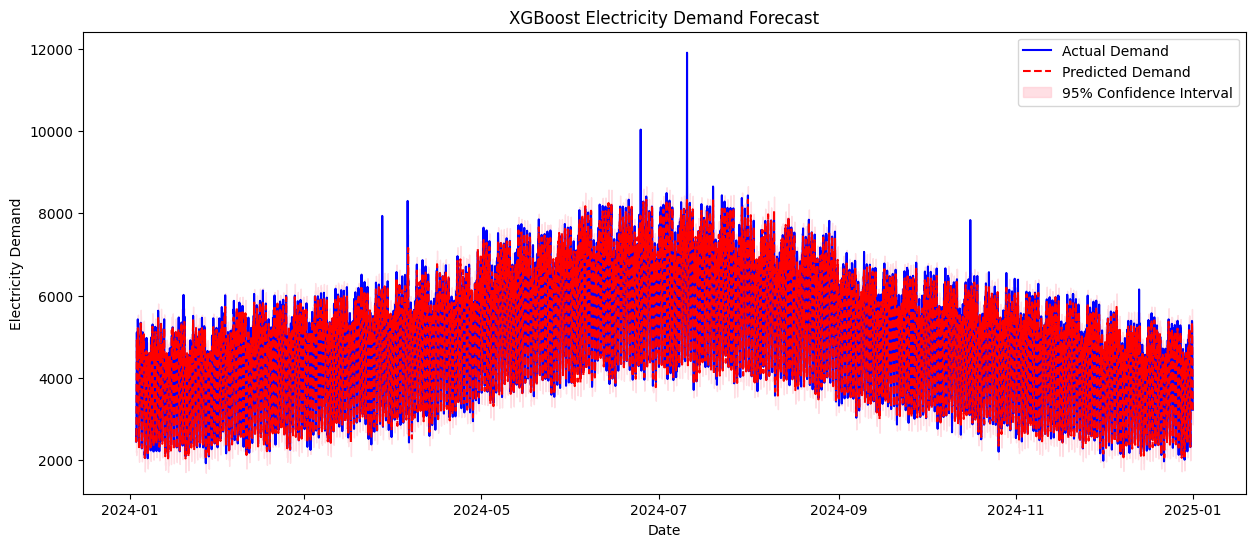

In [27]:
# Visualize the predictions vs actual values
plt.figure(figsize=(15,6))
plt.plot(Y_test.index, Y_test, label='Actual Demand', color='blue')
plt.plot(Y_test.index, predictions_xgb, label='Predicted Demand', color='Red', linestyle='--')
plt.fill_between(Y_test.index, 
                 (predictions_xgb - confidence_interval), 
                 (predictions_xgb + confidence_interval), 
                 color='pink', alpha=0.5, label='95% Confidence Interval')
plt.title("XGBoost Electricity Demand Forecast")
plt.xlabel("Date")
plt.ylabel("Electricity Demand")
plt.legend()
plt.show()

In [28]:
# save the model
joblib.dump(model_xgb, 'xgb_electricity_demand_model.pkl')

['xgb_electricity_demand_model.pkl']

## Confusion Matrix Visualization

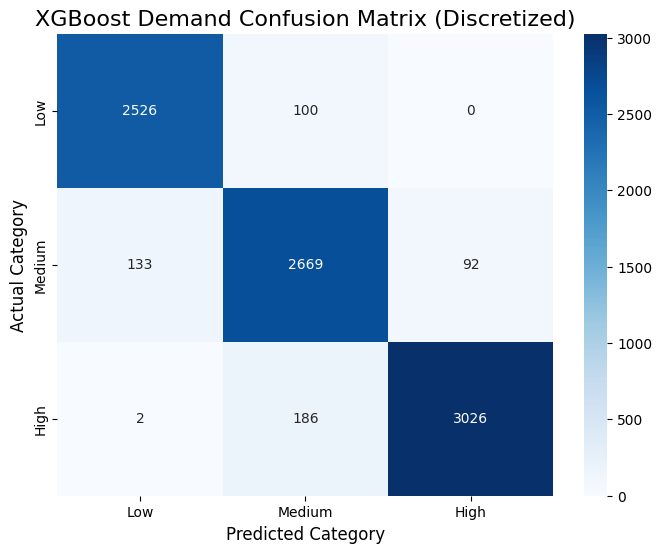

In [29]:
# Confusion Matrix for XGBoost
from sklearn.metrics import confusion_matrix
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Discretization logic based on 33.3% and 66.6% quantiles of training demand
thresholds = Y_train.quantile([0.333, 0.666]).values

def discretize(val):
    if val <= thresholds[0]: return 'Low'
    if val <= thresholds[1]: return 'Medium'
    return 'High'

y_true_cat = Y_test.apply(discretize)
y_pred_cat = pd.Series(predictions_xgb, index=Y_test.index).apply(discretize)
labels = ['Low', 'Medium', 'High']
cm = confusion_matrix(y_true_cat, y_pred_cat, labels=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('XGBoost Demand Confusion Matrix (Discretized)', fontsize=16)
plt.xlabel('Predicted Category', fontsize=12)
plt.ylabel('Actual Category', fontsize=12)
plt.show()